# 最小二乘与线性拟合

学习目标：把拟合写成最小二乘问题，解释残差、投影与正规方程；用 QR、SVD 和伪逆求解，辨认非唯一解、数据敏感性与模型假设。

前置知识：矩阵乘法与转置、列空间与零空间、秩、欧氏范数、正交投影、QR 分解、奇异值分解与伪逆；Python 数组操作。

运行环境：Python 3.12，NumPy、SciPy、Matplotlib；使用实数小矩阵和本地自制数据。

环境准备：见 [数学基础环境与运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 从三个点开始

下面三组数据是为讲解自制的测量示例，不是真实实验记录。时间 $t$ 的单位是秒，位置 $b$ 的单位是厘米。希望用直线 $f(t)=\theta_0+\theta_1t$ 描述它们，其中截距 $\theta_0$ 的单位是厘米，斜率 $\theta_1$ 的单位是厘米每秒。

取候选参数 $\theta_0=1$、$\theta_1=1.5$，先计算预测与观测的差。本章统一把残差定义为“预测值减观测值”。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg

t = np.array([0.0, 1.0, 2.0])
b = np.array([1.0, 2.0, 4.0])
prediction = 1.0 + 1.5 * t
residual = prediction - b

# 两端恰好经过数据点，但中间点仍有 0.5 cm 的残差。
print("预测位置（cm）：", prediction)  # 预期约为 [1. 2.5 4. ]。
print("残差（cm）：", residual)  # 预期约为 [0. 0.5 0. ]。
print("残差平方和（cm²）：", residual @ residual)  # 预期约为 0.25。

预测位置（cm）： [1.  2.5 4. ]
残差（cm）： [0.  0.5 0. ]
残差平方和（cm²）： 0.25


把 $m$ 个观测写成 $A\theta\approx b$。这里 $m,n$ 是正整数，$A\in\mathbb R^{m\times n}$ 是设计矩阵，$n$ 是参数个数，$\theta\in\mathbb R^n$ 是参数列向量，$b\in\mathbb R^m$ 是观测列向量。设计矩阵每行对应一个观测，每列对应一个参数所乘的输入特征。

本例 $m=3,n=2$，第一列全是 $1$，第二列是时间。数学中的列向量在代码中用一维数组表示；@ 表示矩阵乘法或内积，* 表示逐元素乘法。

$$
A=\begin{bmatrix}1&0\\1&1\\1&2\end{bmatrix},\qquad
\theta=\begin{bmatrix}\theta_0\\\theta_1\end{bmatrix},\qquad
b=\begin{bmatrix}1\\2\\4\end{bmatrix}.
$$

In [2]:
A = np.column_stack((np.ones(t.size), t))
theta_trial = np.array([1.0, 1.5])

# 三行对应三个观测；两列对应截距和斜率。
print("A：", A)  # 预期为 [[1. 0.] [1. 1.] [1. 2.]]。
print("A、参数、观测的形状：", A.shape, theta_trial.shape, b.shape)  # 预期为 (3, 2) (2,) (3,)。
print("矩阵形式的预测：", A @ theta_trial)  # 预期约为 [1. 2.5 4. ]。

A： [[1. 0.]
 [1. 1.]
 [1. 2.]]
A、参数、观测的形状： (3, 2) (2,) (3,)
矩阵形式的预测： [1.  2.5 4. ]


## 2 超定系统与最小二乘

$m>n$ 称为超定：方程数多于未知数。它不必无解；是否能精确满足 $A\theta=b$，仍取决于 $b$ 是否属于 $A$ 的列空间。本例若直线经过前两点，参数只能是 $(1,1)$，但它在 $t=2$ 时预测 $3$，不能同时经过第三点。

最小二乘选择使残差平方和最小的参数：

$$
\min_{\theta\in\mathbb R^n}\|A\theta-b\|_2^2
=\min_{\theta\in\mathbb R^n}\sum_{i=1}^{m}r_i^2,
\qquad r=A\theta-b.
$$

$r_i$ 是第 $i$ 个观测的残差，$\|r\|_2=\sqrt{\sum_{i=1}^m r_i^2}$ 是欧氏范数。平方和与范数给出相同的最小化参数。这里把输入时间视为固定值，对各个位置残差赋予相同权重。

In [3]:
theta_two_points = np.array([1.0, 1.0])
r_two_points = A @ theta_two_points - b
b_consistent = A @ theta_two_points

# 相同的超定矩阵，换一组观测就可以有精确解。
print("原观测的残差：", r_two_points)  # 预期为 [ 0. 0. -1.]。
print("平方和：", np.sum(r_two_points**2))  # 预期为 1。
print("可精确拟合的另一组观测：", b_consistent)  # 预期为 [1. 2. 3.]。
print("该组观测的残差范数：", np.linalg.norm(A @ theta_two_points - b_consistent))  # 预期接近 0；本次计算为 0。

原观测的残差： [ 0.  0. -1.]
平方和： 1.0
可精确拟合的另一组观测： [1. 2. 3.]
该组观测的残差范数： 0.0


## 3 投影与正规方程

所有可能的预测 $A\theta$ 都在 $A$ 的列空间中。最小二乘的预测 $p=A\hat\theta$ 是 $b$ 在这个子空间上的正交投影；帽号表示求得的最小二乘参数。投影 $p$ 唯一，参数 $\hat\theta$ 是否唯一还要看矩阵的秩。

残差 $r=p-b$ 与每一列正交，所以 $A^Tr=0$，即正规方程（normal equations）：

$$A^TA\hat\theta=A^Tb.$$

反过来，满足正规方程的参数一定最小化平方和。取任意参数变化 $h\in\mathbb R^n$，展开得到

$$
\|A(\hat\theta+h)-b\|_2^2
=\|r\|_2^2+2h^TA^Tr+\|Ah\|_2^2
=\|r\|_2^2+\|Ah\|_2^2\geq\|r\|_2^2.
$$

先用二维无量纲例子观察投影：列空间是直线 $\operatorname{span}\{(1,1)^T\}$，观测是 $(1,3)^T$，投影是 $(2,2)^T$。

In [4]:
projection_A = np.array([[1.0], [1.0]])
projection_b = np.array([1.0, 3.0])
projection_p = np.array([2.0, 2.0])
projection_r = projection_p - projection_b

# 残差与生成列空间的向量内积为 0；范数平方满足直角三角形关系。
print("残差：", projection_r)  # 预期为 [ 1. -1.]。
print("Aᵀr：", projection_A.T @ projection_r)  # 预期为 [0.]。
print("观测的平方范数：", projection_b @ projection_b)  # 给定观测向量的平方范数为 10。
# 预期约为 10。
print(
    "投影与残差的平方范数之和：",
    projection_p @ projection_p + projection_r @ projection_r,
)

残差： [ 1. -1.]
Aᵀr： [0.]
观测的平方范数： 10.0
投影与残差的平方范数之和： 10.0


图中横、纵坐标是观测向量的第一、第二分量，均无量纲。虚线从 $p$ 指向 $b$，因此表示 $b-p=-r$；它与列空间垂直。几何图使用相同的横纵比例，避免把直角画歪。

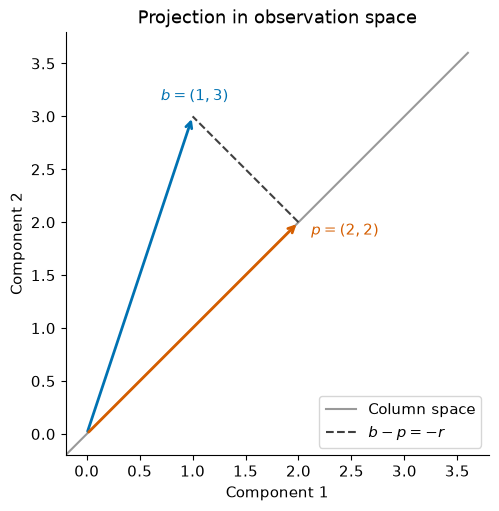

In [5]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
blue, orange = "#0072B2", "#D55E00"
# 在观测空间中画出 b 与投影 p；灰线是 A 的列空间。
fig, ax = plt.subplots(figsize=(5.5, 5), layout="constrained")
ax.plot([-0.2, 3.6], [-0.2, 3.6], color="0.6", label="Column space")
ax.annotate(
    "",
    xy=projection_b,
    xytext=(0, 0),
    arrowprops={"arrowstyle": "->", "color": blue, "lw": 2},
)
ax.annotate(
    "",
    xy=projection_p,
    xytext=(0, 0),
    arrowprops={"arrowstyle": "->", "color": orange, "lw": 2},
)
# 虚线从 p 指向 b，表示 b - p；与本章优化残差 r = p - b 方向相反。
ax.plot([2, 1], [2, 3], "--", color="0.25", label=r"$b-p=-r$")
ax.text(0.7, 3.15, r"$b=(1,3)$", color=blue)
ax.text(2.12, 1.88, r"$p=(2,2)$", color=orange)
ax.set(
    xlim=(-0.2, 3.8),
    ylim=(-0.2, 3.8),
    xlabel="Component 1",
    ylabel="Component 2",
    title="Projection in observation space",
)
# 等比例坐标保留投影与残差之间的直角关系。
ax.set_aspect("equal")
ax.legend(loc="lower right")
# 预期投影 p=(2, 2) 落在 y=x 上，连接 p 与 b=(1, 3) 的虚线与列空间垂直。
plt.show()

## 4 手算正规方程与唯一性

回到三个测量点。逐项相乘可得

$$
A^TA=\begin{bmatrix}3&3\\3&5\end{bmatrix},\qquad
A^Tb=\begin{bmatrix}7\\10\end{bmatrix}.
$$

两条方程相减，得到 $2\hat\theta_1=3$，再代回第一条：$\hat\theta_0=5/6$。所以

$$
\hat\theta=\begin{bmatrix}5/6\\3/2\end{bmatrix},\qquad
r=\begin{bmatrix}-1/6\\1/3\\-1/6\end{bmatrix},\qquad
\|r\|_2^2=1/6.
$$

当且仅当 $A$ 列满秩，即 $\operatorname{rank}(A)=n$，$A^TA$ 可逆。因为对任意 $z\in\mathbb R^n$，$z^TA^TAz=\|Az\|_2^2$；列满秩时，非零 $z$ 不会使这个值为零。此时最小二乘参数唯一，写作 $(A^TA)^{-1}A^Tb$。

下面直接解正规方程核对手算。显式形成 $A^TA$ 适合这里的小例子；实际求解通常采用后面介绍的 QR 或 SVD，也不必先计算矩阵的逆。

In [6]:
normal_matrix = A.T @ A
normal_rhs = A.T @ b
theta_normal = np.linalg.solve(normal_matrix, normal_rhs)
r_normal = A @ theta_normal - b

# 数据量级约为 1，本例可将 1e-12 作为手算与浮点结果的核对尺度。
print("AᵀA：", normal_matrix)  # 预期为 [[3. 3.] [3. 5.]]。
print("Aᵀb：", normal_rhs)  # 预期为 [ 7. 10.]。
print("参数：", theta_normal)  # 预期约为 [0.833333 1.5 ]。
print("与手算参数的差：", theta_normal - np.array([5 / 6, 3 / 2]))  # 预期为 [0. 0.]。
print("残差及平方和：", r_normal, r_normal @ r_normal)  # 预期约为 [-0.166667 0.333333 -0.166667] 0.166667。
print("正交关系 Aᵀr：", A.T @ r_normal)  # 预期 Aᵀr 接近零向量；本次两个分量均为 1e-16 量级。

AᵀA： [[3. 3.]
 [3. 5.]]
Aᵀb： [ 7. 10.]
参数： [0.83333333 1.5       ]
与手算参数的差： [0. 0.]
残差及平方和： [-0.16666667  0.33333333 -0.16666667] 0.1666666666666667
正交关系 Aᵀr： [3.33066907e-16 4.44089210e-16]


NumPy 的 linalg.lstsq 直接接受长方形矩阵。返回的四项依次是参数、残差平方和数组、数值秩、奇异值。rcond 控制把多小的奇异值视为零；设为 None 使用由机器精度和矩阵尺寸决定的默认阈值。

“残差平方和数组”不是残差向量：当矩阵不列满秩或 $m\leq n$ 时，它为空数组，不能据此认定拟合误差为零。需要残差时，始终可以自己计算 $A\hat\theta-b$。

In [7]:
theta_fit, residual_sums, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
r_fit = A @ theta_fit - b

# 这里列满秩且 m > n，所以 residual_sums 含有一个平方和。
print("截距与斜率：", theta_fit)  # 预期约为 [0.833333 1.5 ]。
print("返回的残差平方和：", residual_sums)  # 预期约为 [0.166667]。
print("自行计算的平方和：", r_fit @ r_fit)  # 预期约为 0.166667。
print("数值秩与奇异值：", rank, singular_values)  # 预期约为 2 [2.67624 0.915272]。

截距与斜率： [0.83333333 1.5       ]
返回的残差平方和： [0.16666667]
自行计算的平方和： 0.1666666666666666
数值秩与奇异值： 2 [2.6762432  0.91527173]


在“时间—位置”图中，竖线段表示各观测的残差大小。它们通常不垂直于拟合直线；正交投影发生在由三个观测分量组成的 $\mathbb R^3$ 中，不能把它与下面的二维数据图混为一谈。

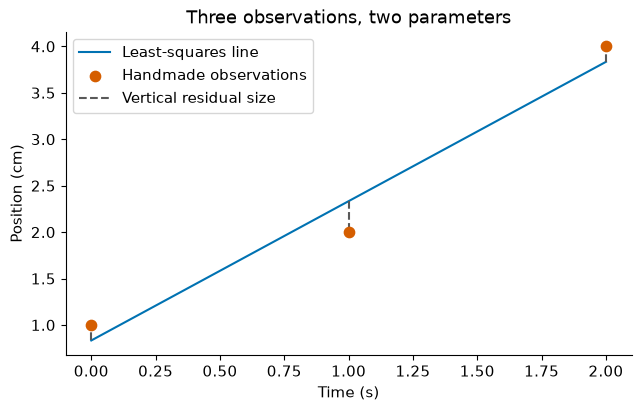

In [8]:
# 用密集时间点绘制拟合直线；原始观测仍只画三个点。
time_grid = np.linspace(0, 2, 100)
fig, ax = plt.subplots(figsize=(6.3, 4), layout="constrained")
ax.plot(
    time_grid,
    theta_fit[0] + theta_fit[1] * time_grid,
    color=blue,
    label="Least-squares line",
)
ax.scatter(t, b, color=orange, s=55, zorder=3, label="Handmade observations")
# 每条竖线连接同一时刻的预测与观测，长度表示残差大小。
ax.vlines(
    t,
    A @ theta_fit,
    b,
    color="0.35",
    linestyles="dashed",
    label="Vertical residual size",
)
ax.set(
    xlabel="Time (s)",
    ylabel="Position (cm)",
    title="Three observations, two parameters",
)
ax.legend()
# 预期拟合直线约为 0.8333+1.5t；首尾点在直线上方，中间点在直线下方。
plt.show()

## 5 用 QR 分解求解

设 $m\geq n$ 且 $A$ 列满秩，约化 QR 分解写成 $A=QR$，其中 $Q\in\mathbb R^{m\times n}$ 满足 $Q^TQ=I_n$，$R\in\mathbb R^{n\times n}$ 是可逆上三角矩阵，$I_n$ 是 $n$ 阶单位矩阵。

把 $b$ 分解成列空间内外两部分，有

$$
\|QR\theta-b\|_2^2
=\|R\theta-Q^Tb\|_2^2+\|(I_m-QQ^T)b\|_2^2.
$$

右侧第二项不随参数变化，第一项可以取零，因此只需解 $R\hat\theta=Q^Tb$。这避免了显式形成 $A^TA$。若矩阵秩亏，$R$ 不再可逆，不能直接套用这个求解步骤。

In [9]:
Q, R = np.linalg.qr(A, mode="reduced")
theta_qr = np.linalg.solve(R, Q.T @ b)

# 先检查分解，再比较最小二乘参数和残差的正交性。
print("Q、R 的形状：", Q.shape, R.shape)  # 预期为 (3, 2) (2, 2)。
print("重构误差：", np.linalg.norm(Q @ R - A))  # 本次数值约为 3.1e-16。
print("正交误差：", np.linalg.norm(Q.T @ Q - np.eye(2)))  # 本次数值约为 2e-16。
print("QR 参数：", theta_qr)  # 预期约为 [0.833333 1.5 ]。
print("与 lstsq 参数的差范数：", np.linalg.norm(theta_qr - theta_fit))  # 预期接近 0；本次计算为 0。
print("Aᵀr：", A.T @ (A @ theta_qr - b))  # 预期 Aᵀr 接近零向量；本次两个分量的绝对值均小于 1e-15。

Q、R 的形状： (3, 2) (2, 2)
重构误差： 3.146735164465678e-16
正交误差： 1.9834297015403628e-16
QR 参数： [0.83333333 1.5       ]
与 lstsq 参数的差范数： 0.0
Aᵀr： [-6.66133815e-16 -8.88178420e-16]


## 6 用 SVD 与伪逆求解

令 $k=\operatorname{rank}(A)$。当 $k>0$ 时，只保留正奇异值的紧致 SVD 为 $A=U_k\Sigma_kV_k^T$，其中 $U_k\in\mathbb R^{m\times k}$、$V_k\in\mathbb R^{n\times k}$ 的列分别正交归一，$\Sigma_k$ 的对角线上是正奇异值 $\sigma_1,\ldots,\sigma_k$。

Moore–Penrose 伪逆为 $A^+=V_k\Sigma_k^{-1}U_k^T$。它给出

$$
\theta_+=A^+b
=\sum_{j=1}^{k}\frac{u_j^Tb}{\sigma_j}v_j,
$$

其中 $u_j,v_j$ 分别是 $U_k,V_k$ 的第 $j$ 列。它对任意形状的实矩阵给出最小欧氏范数的最小二乘解；满列秩时就是唯一解。若 $A=0$，则 $A^+=0$，所选参数也是零。

本例两个奇异值都明显非零，可以直接按公式核对。NumPy 返回的 Vh 是这里的 $V^T$；一般秩亏数据不能把零奇异值直接拿来做除数。

In [10]:
U, s, Vh = np.linalg.svd(A, full_matrices=False)
theta_svd = Vh.T @ ((U.T @ b) / s)
theta_pinv = np.linalg.pinv(A, rcond=1e-12) @ b

# 本例最小奇异值远大于 1e-12 倍最大奇异值，两个方向都保留。
print("奇异值：", s)  # 预期约为 [2.67624 0.915272]。
print("SVD 重构误差：", np.linalg.norm((U * s) @ Vh - A))  # 本次数值约为 4.9e-16。
print("按 SVD 公式求得的参数：", theta_svd)  # 预期约为 [0.833333 1.5 ]。
print("伪逆求得的参数：", theta_pinv)  # 预期约为 [0.833333 1.5 ]。
print("与 QR 参数的差范数：", np.linalg.norm(theta_svd - theta_qr))  # 本次数值约为 2.2e-16。

奇异值： [2.6762432  0.91527173]
SVD 重构误差： 4.856359938494497e-16
按 SVD 公式求得的参数： [0.83333333 1.5       ]
伪逆求得的参数： [0.83333333 1.5       ]
与 QR 参数的差范数： 2.220446049250313e-16


实际计算可以直接用最小二乘求解器，不必先构造整个伪逆。SciPy 的 linalg.lstsq 可通过 lapack_driver="gelsd" 明确选用基于 SVD 的 LAPACK 求解方法；它也能处理秩亏矩阵，返回最小范数解。这里的 cond 与 NumPy 的 rcond 一样用于控制有效秩的相对阈值。

In [11]:
theta_scipy, sums_scipy, rank_scipy, s_scipy = linalg.lstsq(
    A, b, cond=1e-12, lapack_driver="gelsd"
)

# 求解器的参数、平方和与手算一致；这只核对当前小例子。
print("SciPy 参数：", theta_scipy)  # 预期约为 [0.833333 1.5 ]。
print("残差平方和、数值秩：", sums_scipy, rank_scipy)  # 预期约为 0.166667 2。
print("与手算解的差范数：", np.linalg.norm(theta_scipy - theta_normal))  # 本次数值约为 2.5e-16。

SciPy 参数： [0.83333333 1.5       ]
残差平方和、数值秩： 0.16666666666666677 2
与手算解的差范数： 2.482534153247273e-16


## 7 欠定系统中的非唯一解

$m<n$ 称为欠定。矩阵不可能列满秩，因此最小二乘参数不唯一。若同时行满秩，即 $\operatorname{rank}(A)=m$，则任意 $b$ 都有精确解；否则是否有精确解仍取决于 $b$ 所在的位置。

以下例子均无量纲。两条方程是 $\theta_1+\theta_2=1$、$\theta_2+\theta_3=1$；此处三个参数的下标从 $1$ 开始。令自由参数 $a=\theta_2\in\mathbb R$，所有解写成

$$
\theta(a)=\begin{bmatrix}1-a\\a\\1-a\end{bmatrix},\qquad
\|\theta(a)\|_2^2=2(1-a)^2+a^2
=3(a-2/3)^2+2/3.
$$

所以全部解的残差都为零，但只有 $a=2/3$ 时参数范数最小。

In [12]:
A_wide = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 1.0]])
b_wide = np.array([1.0, 1.0])
theta_wide = np.linalg.pinv(A_wide, rcond=1e-12) @ b_wide

print("伪逆选出的参数：", theta_wide)  # 预期约为 [0.333333 0.666667 0.333333]。
print("a      残差范数    参数范数")
for a in [-1.0, 0.0, 2 / 3, 1.0, 2.0]:
    candidate = np.array([1 - a, a, 1 - a])
    # 精确满足方程并不决定唯一参数；比较范数才能区分这些解。
    residual_norm = np.linalg.norm(A_wide @ candidate - b_wide)
    parameter_norm = np.linalg.norm(candidate)
    print(f"{a:5.2f}  {residual_norm:10.6f}  {parameter_norm:10.6f}")  # 所有残差均为 0；给定候选中 a=2/3 的参数范数最小，约 0.816497。

伪逆选出的参数： [0.33333333 0.66666667 0.33333333]
a      残差范数    参数范数
-1.00    0.000000    3.000000
 0.00    0.000000    1.414214
 0.67    0.000000    0.816497
 1.00    0.000000    1.000000
 2.00    0.000000    2.449490


## 8 秩亏系统中的最小范数解

参数非唯一也会发生在超定系统中。把设计矩阵的两列设成同一个向量，得到

$$
A_d=\begin{bmatrix}1&1\\2&2\\3&3\end{bmatrix},\qquad
b_d=\begin{bmatrix}1\\2\\4\end{bmatrix}.
$$

这些量均无量纲。下标 $d$ 仅用于标记这组秩亏数据。预测只取决于参数之和 $c=\theta_1+\theta_2$，于是问题变成最小化 $(c-1)^2+(2c-2)^2+(3c-4)^2$。一维正规方程为 $14c=17$。

全部最小二乘解因此满足参数之和为 $17/14$。它们可以写成

$$
\theta=\begin{bmatrix}17/28\\17/28\end{bmatrix}
+a\begin{bmatrix}1\\-1\end{bmatrix},\qquad a\in\mathbb R.
$$

预测相同，残差平方和都为 $5/14$；但最小参数范数在 $a=0$ 时取得。

In [13]:
A_deficient = np.array([[1.0, 1.0], [2.0, 2.0], [3.0, 3.0]])
b_deficient = np.array([1.0, 2.0, 4.0])
theta_deficient, sums_deficient, rank_deficient, s_deficient = np.linalg.lstsq(
    A_deficient, b_deficient, rcond=1e-12
)
null_direction = np.array([1.0, -1.0])

# 返回的平方和数组为空，但自行算出的最小平方和约为 0.357143。
print("数值秩、返回的平方和数组：", rank_deficient, sums_deficient)  # 预期为 1 []。
print("最小范数参数：", theta_deficient)  # 预期约为 [0.607143 0.607143]。
print("零空间方向的像：", A_deficient @ null_direction)  # 预期为 [0. 0. 0.]。
for a in [-2.0, 0.0, 2.0]:
    candidate = theta_deficient + a * null_direction
    r_candidate = A_deficient @ candidate - b_deficient
    # 三组残差平方和均约 0.357143；参数范数依次约 2.95588、0.85863、2.95588。
    print(
        f"a={a:4.1f}，平方和={r_candidate @ r_candidate:.6f}，"
        f"参数范数={np.linalg.norm(candidate):.6f}"
    )

数值秩、返回的平方和数组： 1 []
最小范数参数： [0.60714286 0.60714286]
零空间方向的像： [0. 0. 0.]
a=-2.0，平方和=0.357143，参数范数=2.955883
a= 0.0，平方和=0.357143，参数范数=0.858630
a= 2.0，平方和=0.357143，参数范数=2.955883


为什么伪逆选出的解范数最小？由紧致 SVD，$p=AA^+b=U_kU_k^Tb$ 是唯一投影，而 $\theta_+=A^+b$ 属于 $A$ 的行空间，即 $V_k$ 的列空间。

任一其他最小二乘解都具有相同的预测，因此写成 $\theta_++z$，其中 $z\in\mathbb R^n$ 满足 $Az=0$。行空间与零空间正交，所以

$$
\|\theta_++z\|_2^2=\|\theta_+\|_2^2+\|z\|_2^2.
$$

只有 $z=0$ 才达到最小参数范数。这里先最小化残差，再在全部最小二乘解中最小化参数范数；没有把这两个目标相加。范数以当前参数的数值尺度为准，也不自动表示参数符合实际物理约束。

In [14]:
z = 2.0 * null_direction
theta_shifted = theta_deficient + z

# 代数证明适用于全部解；下面只核对其中一个非零的零空间位移。
print("正交内积 θ₊ᵀz：", theta_deficient @ z)  # 本次数值约为 -4.4e-16。
print("位移前后的预测差：", A_deficient @ theta_shifted - A_deficient @ theta_deficient)  # 预期两组预测接近相等；本次差向量的最大绝对值约 4.4e-16。
print("新参数平方范数：", theta_shifted @ theta_shifted)  # 预期约为 8.73724。
print("两个正交分量平方范数之和：", theta_deficient @ theta_deficient + z @ z)  # 预期约为 8.73724。
# 预期 Aᵀr 接近零向量；本次两个分量均约 -4.4e-15。
print(
    "残差与列空间的正交关系：",
    A_deficient.T @ (A_deficient @ theta_deficient - b_deficient),
)

正交内积 θ₊ᵀz： -4.440892098500626e-16
位移前后的预测差： [ 0.0000000e+00  0.0000000e+00 -4.4408921e-16]
新参数平方范数： 8.737244897959181
两个正交分量平方范数之和： 8.737244897959183
残差与列空间的正交关系： [-4.4408921e-15 -4.4408921e-15]


## 9 小扰动为什么会改变参数

当两列几乎相同，区分它们的证据很弱。构造无量纲矩阵

$$
A_\varepsilon=\begin{bmatrix}1&1\\1&1+\varepsilon\\1&1-\varepsilon\end{bmatrix},\qquad
b_0=A_\varepsilon\begin{bmatrix}1\\1\end{bmatrix},\qquad
\delta b=\eta\begin{bmatrix}0\\1\\-1\end{bmatrix},
$$

其中 $\varepsilon>0$ 控制两列的接近程度，$\eta=10^{-6}$ 控制观测扰动幅度。可以代回验证：把观测改成 $b_0+\delta b$ 后，精确解变成 $(1-\eta/\varepsilon,1+\eta/\varepsilon)^T$。当 $\varepsilon$ 很小时，小观测变化会引起大参数变化。

In [15]:
eta = 1e-6
delta_b = eta * np.array([0.0, 1.0, -1.0])
theta_reference = np.array([1.0, 1.0])

for epsilon in [1e-2, 1e-6]:
    A_near = np.array([[1.0, 1.0], [1.0, 1.0 + epsilon], [1.0, 1.0 - epsilon]])
    b_original = A_near @ theta_reference
    b_changed = b_original + delta_b
    theta_changed = np.linalg.lstsq(A_near, b_changed, rcond=1e-12)[0]
    # 最小二乘可以几乎零残差地拟合两组观测，参数却可能相差很大。
    print(f"ε={epsilon:.0e}，参数={theta_changed}")  # ε=1e-2 时参数约 [0.9999, 1.0001]；ε=1e-6 时约 [0, 2]。
    # 观测变化均约 1.414e-6；参数变化分别约 1.414e-4、1.414。
    print(
        "观测变化、参数变化的范数：",
        np.linalg.norm(delta_b),
        np.linalg.norm(theta_changed - theta_reference),
    )
    print("新观测的残差范数：", np.linalg.norm(A_near @ theta_changed - b_changed))  # 两次残差范数都接近 0，本次均小于 2e-15。

ε=1e-02，参数=[0.9999 1.0001]


观测变化、参数变化的范数： 1.414213562373095e-06 0.0001414213562248902
新观测的残差范数： 1.4217791915866692e-15
ε=1e-06，参数=[-2.22044391e-10  2.00000000e+00]
观测变化、参数变化的范数： 1.414213562373095e-06 1.4142135626871128
新观测的残差范数： 1.7342238036525468e-15


列满秩矩阵的二范数条件数为 $\kappa_2(A)=\sigma_{\max}/\sigma_{\min}$，即最大与最小奇异值之比。它较大时，某些方向的数据误差可能被显著放大；不表示所有方向的扰动都会达到同样影响。

在精确算术中，$\kappa_2(A^TA)=\kappa_2(A)^2$。因此显式构造正规方程可能恶化数值求解。QR 或 SVD 避免这个构造，但无法消除原始数据本身对参数的敏感性。

In [16]:
# A_near 保留上一个单元中 ε=1e-6 的矩阵。
condition_A = np.linalg.cond(A_near)
condition_normal = np.linalg.cond(A_near.T @ A_near)
print("κ₂(A)：", condition_A)  # 预期约为 2.44949e+06。
print("κ₂(A)²：", condition_A**2)  # 预期约为 6e+12。
print("浮点计算的 κ₂(AᵀA)：", condition_normal)  # 预期约为 5.99911e+12。
# 最后两项数量级相近；严重病态时，浮点计算不保证复现精确等式。

κ₂(A)： 2449489.742849124
κ₂(A)²： 6000000000323.068
浮点计算的 κ₂(AᵀA)： 5999106755913.246


把很小的奇异值截断为零可以忽略敏感方向，但也改变了有效秩。下面用两个相对阈值拟合同一组扰动后的数据：$10^{-12}$ 保留两个方向，$10^{-4}$ 只保留一个。

数学上非零的奇异值被丢弃时，求的是截断矩阵对应的解，不再是原矩阵的精确最小二乘解。需要同时查看原矩阵下的残差与参数范数，并根据数据精度说明阈值依据。

In [17]:
print("rcond     数值秩  原矩阵残差范数  参数范数")
for cutoff in [1e-12, 1e-4]:
    theta_cut, _, rank_cut, s_cut = np.linalg.lstsq(A_near, b_changed, rcond=cutoff)
    residual_size = np.linalg.norm(A_near @ theta_cut - b_changed)
    # 本次两行数值秩为 2、1；残差约 1.7e-15、1.4e-6，参数范数约 2、1.414。
    print(
        f"{cutoff:7.0e}   {rank_cut}       {residual_size:.6e}   "
        f"{np.linalg.norm(theta_cut):.6f}"
    )
print("奇异值及其比值：", s_cut, s_cut[-1] / s_cut[0])  # 预期约为 [2.44949 1e-06] 4.08248e-07。
# 较大的阈值会减小参数范数，同时留下原始方程中的非零残差。

rcond     数值秩  原矩阵残差范数  参数范数
  1e-12   2       1.734224e-15   2.000000
  1e-04   1       1.414214e-06   1.414214
奇异值及其比值： [2.44948974e+00 1.00000000e-06] 4.0824829045287205e-07


## 10 综合应用：拟合之外还要看什么

生成九个自制测量点：时间 $t_i$ 在 $0$ 到 $4$ 秒之间，位置以厘米计，生成关系为 $b_i=2+1.2t_i+0.35t_i^2+e_i$。下标 $i=1,\ldots,9$ 表示观测序号；$e_i$ 是下方明确列出的固定小扰动，没有假定它们来自某个随机分布。三个系数的单位依次为厘米、厘米每秒、厘米每平方秒。

分别使用直线和二次曲线。二次曲线虽然关于时间不是直线，但关于三个待求系数仍是线性的，因此也能用设计矩阵的三列 $1,t,t^2$ 做线性最小二乘。

In [18]:
times = np.linspace(0.0, 4.0, 9)
fixed_errors = np.array([0.05, -0.08, 0.04, 0.03, -0.05, 0.06, -0.03, 0.02, -0.04])
positions = 2.0 + 1.2 * times + 0.35 * times**2 + fixed_errors
A_line = np.column_stack((np.ones(times.size), times))
A_curve = np.column_stack((np.ones(times.size), times, times**2))
theta_line, _, rank_line, _ = np.linalg.lstsq(A_line, positions, rcond=None)
theta_curve, _, rank_curve, _ = np.linalg.lstsq(A_curve, positions, rcond=None)
r_line = A_line @ theta_line - positions
r_curve = A_curve @ theta_curve - positions

# 两种设计矩阵都列满秩；降低平方和还不足以完成模型判断。
print("直线参数、秩、平方和：", theta_line, rank_line, r_line @ r_line)  # 预期约为 [1.19467 2.59433] 2 2.33429。
print("二次曲线参数、秩、平方和：", theta_curve, rank_curve, r_curve @ r_curve)  # 预期约为 [2.00376 1.20732 0.346753] 3 0.0197154。

直线参数、秩、平方和： [1.19466667 2.59433333] 2 2.334293333333331
二次曲线参数、秩、平方和： [2.00375758 1.20732035 0.34675325] 3 0.01971541125541131


先检查最小二乘有没有算对，再检查模型。下方用 $\|A^Tr\|_2/(\|A\|_2\|b\|_2)$ 表示按输入尺度归一化的正交误差，分母在本例中非零；这里矩阵的二范数等于最大奇异值。

即使 $A^Tr$ 接近零，残差随时间仍可能出现系统弯曲。这表示求解满足最小二乘条件，却未必选对了函数形式。

In [19]:
for name, design, residual in [
    ("直线", A_line, r_line),
    ("二次曲线", A_curve, r_curve),
]:
    scale = np.linalg.norm(design, ord=2) * np.linalg.norm(positions)
    relative_orthogonality = np.linalg.norm(design.T @ residual) / scale
    # 当前输入尺度适中，正交误差应远小于 1e-12。
    print(f"{name}：归一化正交误差={relative_orthogonality:.3e}")  # 预期两种拟合的归一化正交误差接近 0；本次均小于 1e-14。

直线：归一化正交误差=1.557e-16
二次曲线：归一化正交误差=3.923e-16


左图显示位置与拟合结果，右图显示“预测减观测”的残差。直线残差的弯曲形状提示缺少曲率；二次曲线的残差较小。两幅图使用相同颜色区分模型，残差图的零线用于判断误差方向。

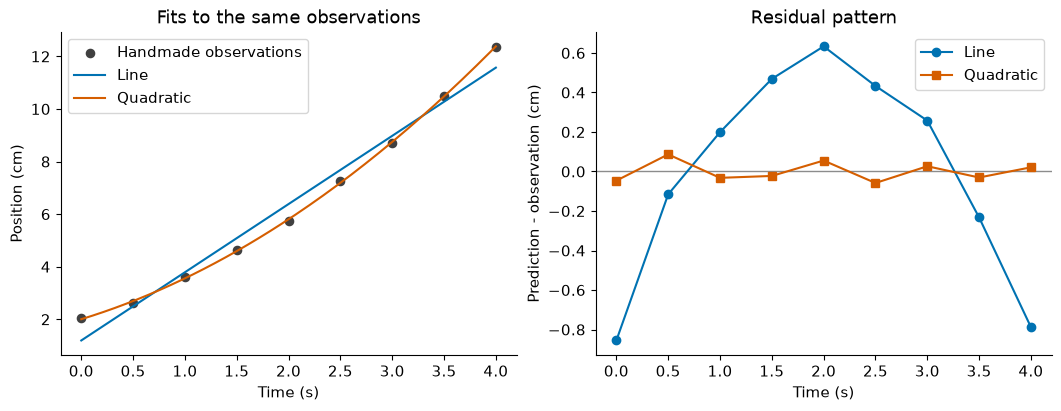

In [20]:
# 两种设计矩阵共用同一时间网格，列分别对应常数、一次项和二次项。
grid = np.linspace(0.0, 4.0, 150)
grid_line = np.column_stack((np.ones(grid.size), grid))
grid_curve = np.column_stack((np.ones(grid.size), grid, grid**2))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), layout="constrained")
axes[0].scatter(times, positions, color="0.25", s=35, label="Handmade observations")
axes[0].plot(grid, grid_line @ theta_line, color=blue, label="Line")
axes[0].plot(grid, grid_curve @ theta_curve, color=orange, label="Quadratic")
axes[0].set(
    xlabel="Time (s)",
    ylabel="Position (cm)",
    title="Fits to the same observations",
)
# 右图改画预测减观测，借助零线观察误差是否呈现系统性模式。
axes[1].axhline(0, color="0.55", linewidth=1)
axes[1].plot(times, r_line, "o-", color=blue, label="Line")
axes[1].plot(times, r_curve, "s-", color=orange, label="Quadratic")
axes[1].set(
    xlabel="Time (s)",
    ylabel="Prediction - observation (cm)",
    title="Residual pattern",
)
for ax in axes:
    ax.legend()
# 预期二次曲线更贴近这些点；右图直线残差有弯曲模式，二次残差更接近零线。
plt.show()

增加设计矩阵的列会扩大或保持可选预测的空间，因此训练数据上的最小残差不会增大。这是几何性质，不能单独证明更复杂的模型更合理。

下面取未参与拟合的 $5$ 秒和 $6$ 秒，用已知的自制生成关系提供无扰动参考值。两点位于训练区间之外，属于外推；结果只针对这组生成机制。真实应用中还需要独立观测、残差结构与问题背景，不能仅凭较低的训练误差认可模型。

In [21]:
new_times = np.array([5.0, 6.0])
reference_positions = 2.0 + 1.2 * new_times + 0.35 * new_times**2
new_line_design = np.column_stack((np.ones(new_times.size), new_times))
new_curve_design = np.column_stack((np.ones(new_times.size), new_times, new_times**2))
new_line = new_line_design @ theta_line
new_curve = new_curve_design @ theta_curve

# 参考值由我们设定的生成关系给出，未用于估计上面的参数。
print("新时间（s）：", new_times)  # 预期为 [5. 6.]。
print("无扰动参考位置（cm）：", reference_positions)  # 预期约为 [16.75 21.8 ]。
print("直线的绝对误差（cm）：", np.abs(new_line - reference_positions))  # 预期约为 [2.58367 5.03933]。
print("二次曲线的绝对误差（cm）：", np.abs(new_curve - reference_positions))  # 预期约为 [0.0408095 0.0692035]。

新时间（s）： [5. 6.]
无扰动参考位置（cm）： [16.75 21.8 ]
直线的绝对误差（cm）： [2.58366667 5.03933333]
二次曲线的绝对误差（cm）： [0.04080952 0.06920346]


## 本章小结

最小二乘把观测投影到设计矩阵的列空间，正规方程表达残差与列空间的正交关系。预测唯一；参数唯一还要求列满秩。

QR 和 SVD 可以直接求解。欠定或秩亏时，伪逆在全部最小二乘解中选出欧氏范数最小的一项。近相关的列、奇异值阈值和观测扰动会影响参数；小残差既不保证参数稳定，也不保证模型假设合理。

理解自查：残差与列空间正交时，为什么仍要分别检查参数是否唯一、对扰动是否敏感，以及模型形式是否合理？

## 练习

（1）把三个位置改为 $2,2,5$ 厘米，时间仍为 $0,1,2$ 秒。先手算 $A^TA$ 和 $A^Tb$，再求截距、斜率与残差平方和。用代码核对参数和 $A^Tr$；说明这里为什么参数唯一。

In [22]:
exercise_t = np.array([0.0, 1.0, 2.0])
exercise_b = np.array([2.0, 2.0, 5.0])
exercise_A = np.column_stack((np.ones(exercise_t.size), exercise_t))

# 在这里写出手算参数，再与 np.linalg.lstsq 的结果比较。
# 计算残差平方和与 Aᵀr，并解释列满秩的作用。

（2）对欠定系统 $\theta_1+\theta_2=1$、$\theta_2+\theta_3=1$，新增约束 $\theta_2=0$。原先的最小范数解是否仍满足约束？先求满足三条约束的参数，再比较它与原解的残差和范数。解释“无约束最小范数”为什么不等于“满足任意新约束”。所有量均无量纲。

In [23]:
exercise_wide = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 1.0]])
exercise_rhs = np.array([1.0, 1.0])

# 先求原来的最小范数解；另写出满足 θ₂=0 的参数。
# 分别检查两条原方程、新增约束以及参数范数。

（3）下面的无量纲矩阵两列几乎相同。先预测 rcond 取 $10^{-12}$ 和 $10^{-4}$ 时保留的数值秩，再计算两组解的残差和范数。解释代数秩与数值秩的区别，并说明仅凭解范数较小能否决定应采用哪个阈值。

In [24]:
exercise_near = np.array([[1.0, 1.0], [1.0, 1.0 + 1e-7], [1.0, 1.0 - 1e-7]])
exercise_target = exercise_near @ np.array([0.5, 1.5])

# 打印奇异值，再用两个 rcond 求解并比较。
# 把阈值选择与可接受的数据误差联系起来，不只比较残差是否很小。

（4）将直线拟合的三次输入时间都改为 $2$ 秒，位置取 $3.9,4.0,4.1$ 厘米。预测设计矩阵的秩，求一个最小二乘解，并找出另一组具有相同预测的截距和斜率。解释为什么只在一个时间点重复测量无法分别确定截距与斜率，以及为什么训练残差很小仍不足以支持外推。

In [25]:
exercise_times = np.array([2.0, 2.0, 2.0])
exercise_positions = np.array([3.9, 4.0, 4.1])
exercise_design = np.column_stack((np.ones(exercise_times.size), exercise_times))

# 求最小二乘解，构造一项非零的零空间位移，再比较两个解的预测。
# 选择一个不同的时间，观察两组参数是否仍给出相同的位置。

## 练习提示与解析

以下对应练习（4）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：设计矩阵的第二列与第一列成比例。

提示 2：拟合只能确定在 2 秒处的位置；沿参数零空间移动不会改变这个位置。

### 练习（4）参考解析

设计矩阵各行为 $(1,2)$，秩为 1。使三次预测相同且平方误差最小的预测是观测均值 4 cm，因此全部最小二乘参数满足 $\theta_0+2\theta_1=4$。

在题目给定单位与参数布局下，lstsq 返回的最小欧氏范数解为 $(0.8,1.6)^T$；加上零空间向量 $(2,-1)^T$，得到 $(2.8,0.6)^T$。两者在 2 秒处都预测 4 cm，残差按预测减观测为 $(0.1,0,-0.1)^T$，平方和为 0.02 cm²；但在 0 秒处分别预测 0.8、2.8 cm。重复测量能约束已测时刻的位置，不能凭空确定时间变化的斜率。

## 参考与引用来源

以下官方或第一方资料在写作前核查。数学推导与示例数据按本章问题组织；有限次计算用于核对，不代替证明。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Stanford EE263 | Stephen Boyd，[Lecture 5: Least-squares](https://ee263.stanford.edu/archive/ls.pdf)，讲义页码 5–2 至 5–10：超定、投影、正规方程、平方和展开与 QR；[Lecture 6: Least-squares applications](https://ee263.stanford.edu/archive/ls-app.pdf)，6–2 至 6–5、6–9 至 6–10、6–15 至 6–19：基函数拟合、增加特征与模型验证；[Lecture 8: Least-norm solutions](https://ee263.stanford.edu/archive/min-norm.pdf)，8–2 至 8–7：欠定解集及最小范数；[Lecture 16: SVD applications](https://ee263.stanford.edu/archive/svd.pdf)，16–2 至 16–6、16–15 至 16–21：一般伪逆解、子空间、条件数与小奇异值。 |
| MIT OpenCourseWare | 18.06SC [Projections onto subspaces](https://ocw.mit.edu/courses/18-06sc-linear-algebra-fall-2011/198bde3a6536b62989b6cc09495575c1_MIT18_06SCF11_Ses2.3sum.pdf)，第 1–3 页：投影、数据图与观测空间的区别、列满秩与正规矩阵可逆；18.335J [Week 4, Lecture 9](https://ocw.mit.edu/courses/18-335j-introduction-to-numerical-methods-spring-2019/pages/week-4/)：正规方程使条件数平方及 QR 替代。 |
| LAPACK / Netlib | [Linear Least Squares Problems](https://www.netlib.org/lapack/lug/node27.html)：形状、秩与求解器类型；LAPACK 3.12.1 [DGELSD](https://www.netlib.org/lapack/explore-html/d9/d67/group__gelsd_ga0bee7e1b9e7e43f59ecf2419b2759c42.html)，Purpose、RCOND：SVD 最小范数求解与有效秩。 |
| NumPy | 2.5 文档：[lstsq](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html)，Parameters、Returns：阈值、最小范数及残差平方和空数组条件；[solve](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html)：方阵满秩条件；[qr](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html)、[svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)：约化形状、返回顺序与重构；[pinv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.pinv.html)：SVD 伪逆与阈值；[cond](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html)：默认二范数条件数。 |
| SciPy | [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)，Parameters、Returns、Notes：cond、gelsd 与其他 LAPACK 驱动；本章实际使用 SciPy 1.18.1。 |
| NIST/SEMATECH | [4.4.4. How can I tell if a model fits my data?](https://www.itl.nist.gov/div898/handbook/pmd/section4/pmd44.htm)，Residual Analysis、Graphical Analysis：残差结构与模型函数形式的检查；本章统一使用预测减观测的残差符号。 |
| Matplotlib | [Axes.vlines](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.vlines.html)，x、ymin、ymax：残差竖线；[Axes.annotate](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html)，xy、xytext、arrowprops：向量箭头。 |